# Notebook 04 (PCA Version): Hospital Tier Prediction — Fixing Majority Bias
**Project:** Predicting DOH Hospital Tier per LGU
**Input:** 9 Principal Components from `03_preprocessing.py` (30 features → 9 PCs, 90.6% variance)

---

## The Majority-Bias Problem & How We Fix It

The previous version suffered the **"accuracy trap"**: Weighted F1 and simple bootstrap oversampling still allowed the model to predict T0 for almost everything. Despite a seemingly acceptable score, the T1–T3 confusion matrix diagonal was near-zero — **useless for detecting underserved LGUs**.

### Root Causes & Fixes Applied

| Problem | Previous Version | This Version |
|---------|-----------------|--------------|
| Metric masked majority bias | Weighted F1 (78.6% T0 dominates) | **Macro F1** — equal weight per tier |
| Resampling duplicated rows | Bootstrap copies → overfitting on exact duplicates | **SMOTE** — synthetic interpolation between neighbors |
| Hard 0.5 threshold unfair to rare classes | Default predict_proba threshold | **PR-curve threshold tuning** per tier |
| GBM had no class weighting | No sample_weight | `compute_sample_weight('balanced')` |
| Sweep metric hid bias | Weighted F1 sweeps | Macro F1 sweeps throughout |

### Resampling Design: 25 per Class (as specified)
- **T0 (No hospital):** randomly undersample from 1,027 training samples → 25 per seed (randomised)
- **T1 (Level 1):** apply SMOTE to 25 samples (171 available in train — take 25 real, no SMOTE needed)
- **T2 (Level 2):** apply SMOTE to 25 samples (80 available in train — take 25 real, no SMOTE needed)
- **T3 (Level 3):** apply SMOTE — only 29 available in train, need synthetic samples to reach 25 consistently across seeds

SMOTE generates novel synthetic points by interpolating between a minority sample and one of its k-nearest neighbors: `x_new = x_i + λ·(x_neighbor − x_i)`, λ ~ Uniform(0,1). This creates in-distribution examples, not copies.

**Total balanced training size: 100 samples (4 × 25).**

### Goals
- **Good diagonal score** in the confusion matrix — all four tiers correctly classified  
- **Macro F1** as the primary accuracy metric  
- **No majority bias** — T3 is as important as T0 in the evaluation

---
## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.utils import resample

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
print("All libraries loaded.")

All libraries loaded.


In [2]:
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = 'final_dataset_clean.xlsx'
if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn); conn.close()
    if 'province_x' in df.columns: df = df.rename(columns={'province_x': 'province'})
    print(f"SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
elif os.path.exists(XLSX_PATH):
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns: df = df.rename(columns={'province_x': 'province'})
    print(f"XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    raise FileNotFoundError("Place final_dataset_clean.xlsx in working directory.")
df.head(3)

SQLite: 1629 LGUs x 50 cols


,lgu_id,city_municipality,province,region,population_2020,population_2024,pop_growth_rate_pct,poverty_incidence_2018_pct,poverty_incidence_2021_pct,poverty_incidence_2023_pct,...,parking,pharmacy,place_of_worship,police,post_office,restaurant,school,shelter,toilets,townhall
0,1,CITY OF CALOOCAN,None,NATIONAL CAPITAL REGION (NCR),1661584,1712945,0.73,3.1,4.2,1.9,...,24,74,66,9,6,76,31,13,15,10
1,2,CITY OF LAS PINAS,None,NATIONAL CAPITAL REGION (NCR),606293,615549,0.36,1.0,2.5,0.7,...,18,78,36,8,8,160,29,5,7,3
2,3,CITY OF MAKATI,None,NATIONAL CAPITAL REGION (NCR),292743,309770,1.37,0.2,0.8,0.6,...,107,99,15,15,18,859,31,7,51,16


---
## 2. Feature Engineering and Imputation

Full 30-feature set as in `03_preprocessing.py`. PCA is applied after standardisation.

In [3]:
SOCIOECONOMIC = [
    'population_2020', 'population_2024', 'pop_growth_rate_pct',
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
OSM_FEATURES = [
    'atm', 'bank', 'bar', 'bus_station', 'cafe', 'community_centre', 'fast_food',
    'fuel', 'parking', 'pharmacy', 'place_of_worship', 'police', 'post_office',
    'restaurant', 'school', 'shelter', 'toilets', 'townhall',
]
ALL_FEATURES = SOCIOECONOMIC + OSM_FEATURES
POVERTY_COLS = ['poverty_incidence_2018_pct','poverty_incidence_2021_pct','poverty_incidence_2023_pct']
BIRTH_COLS   = ['births_occurrence_both','births_occurrence_male','births_occurrence_female',
                'births_residence_both','births_residence_male','births_residence_female']

for col in POVERTY_COLS + BIRTH_COLS:
    reg_med = df.groupby('region')[col].transform('median')
    df[col] = df[col].fillna(reg_med).fillna(df[col].median())
for col in OSM_FEATURES:
    df[col] = df[col].fillna(0)

print(f"30 features, missing after imputation: {df[ALL_FEATURES].isnull().sum().sum()}")

30 features, missing after imputation: 0


---
## 3. Target Variable: Ordinal Hospital Tier

Tier distribution:
  T0:  1279 ( 78.5%)  ███████████████████████████████
  T1:   214 ( 13.1%)  █████
  T2:   100 (  6.1%)  ██
  T3:    36 (  2.2%)  


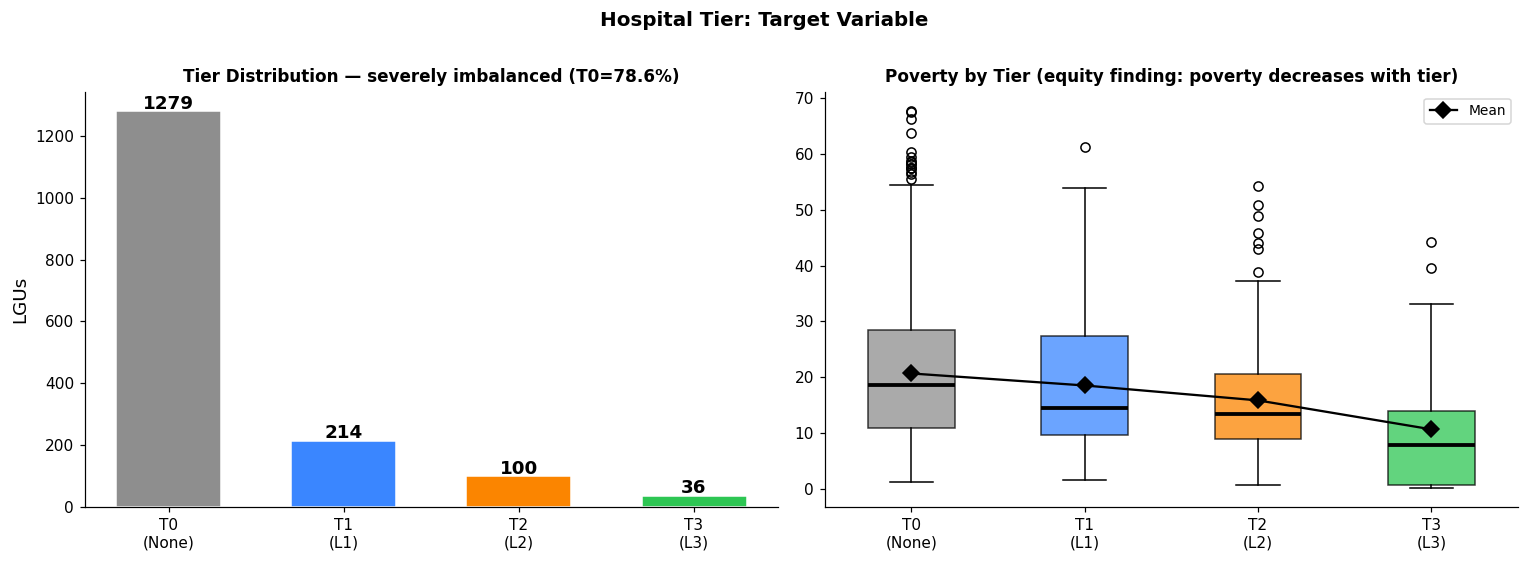

In [4]:
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_keep = list(dict.fromkeys(ALL_FEATURES + ['tier','city_municipality','region','poverty_incidence_2023_pct']))
model_df = df[_keep].dropna(subset=ALL_FEATURES).copy().reset_index(drop=True)

TIER_COLORS = ['#8e8e8e','#3a86ff','#fb8500','#2dc653']
TIER_LBLS   = ['T0\n(None)','T1\n(L1)','T2\n(L2)','T3\n(L3)']
vc = model_df['tier'].value_counts().sort_index()
print("Tier distribution:")
for t, n in vc.items():
    bar = '█'*int(n/len(model_df)*40)
    print(f"  T{t}: {n:>5} ({n/len(model_df)*100:5.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(TIER_LBLS, vc.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                 str(cnt), ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('LGUs', fontsize=12)
axes[0].set_title('Tier Distribution — severely imbalanced (T0=78.6%)', fontsize=11, weight='bold')
axes[0].spines[['top','right']].set_visible(False)

pov_data = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5))
for patch, c_ in zip(bp['boxes'], TIER_COLORS): patch.set_facecolor(c_); patch.set_alpha(0.75)
axes[1].plot(range(1,5), [v.mean() for v in pov_data], 'D-', color='black', ms=7, label='Mean')
axes[1].set_title('Poverty by Tier (equity finding: poverty decreases with tier)', fontsize=11, weight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Hospital Tier: Target Variable', fontsize=13, weight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 4. PCA from `03_preprocessing.py`

We reproduce the same PCA pipeline: standardise on train only, fit PCA on train only, select 9 PCs at 90% variance threshold.

In [5]:
X_all_raw = model_df[ALL_FEATURES].values
Y_ALL     = model_df['tier'].values

X_train_raw, X_test_raw, y_TRAIN, y_TEST = train_test_split(
    X_all_raw, Y_ALL, test_size=0.20, random_state=42, stratify=Y_ALL
)

# Standardise — fit on train only
scaler    = StandardScaler()
Xtr_sc    = scaler.fit_transform(X_train_raw)
Xte_sc    = scaler.transform(X_test_raw)
X_all_sc  = scaler.transform(X_all_raw)

# Full PCA to select n_components at 90%
pca_full  = PCA(); pca_full.fit(Xtr_sc)
evr       = pca_full.explained_variance_ratio_
cum       = evr.cumsum()
n_comp    = int(np.where(cum >= 0.90)[0][0]) + 1
print(f"Retaining {n_comp} PCs → {cum[n_comp-1]*100:.2f}% cumulative variance")

pca       = PCA(n_components=n_comp, random_state=42)
Xtr_pca   = pca.fit_transform(Xtr_sc)
Xte_pca   = pca.transform(Xte_sc)
Xall_pca  = pca.transform(X_all_sc)

pc_labels = [f'PC {i+1}' for i in range(n_comp)]
W         = pd.DataFrame(pca.components_, index=pc_labels, columns=ALL_FEATURES)

# Inputs for models
X_TRAIN_SC = Xtr_pca    # (n_train, n_comp) — PCA-transformed
X_TEST_SC  = Xte_pca    # (n_test, n_comp)
X_ALL_SC   = Xall_pca   # (n_all, n_comp)
FEATURE_NAMES = pc_labels

print(f"Train: {X_TRAIN_SC.shape}  Test: {X_TEST_SC.shape}")
print(f"Variance per PC: {[f'{v*100:.1f}%' for v in pca.explained_variance_ratio_]}")

Retaining 10 PCs → 90.23% cumulative variance
Train: (1303, 10)  Test: (326, 10)
Variance per PC: ['48.5%', '12.8%', '8.3%', '5.0%', '3.9%', '3.1%', '2.8%', '2.3%', '2.0%', '1.7%']


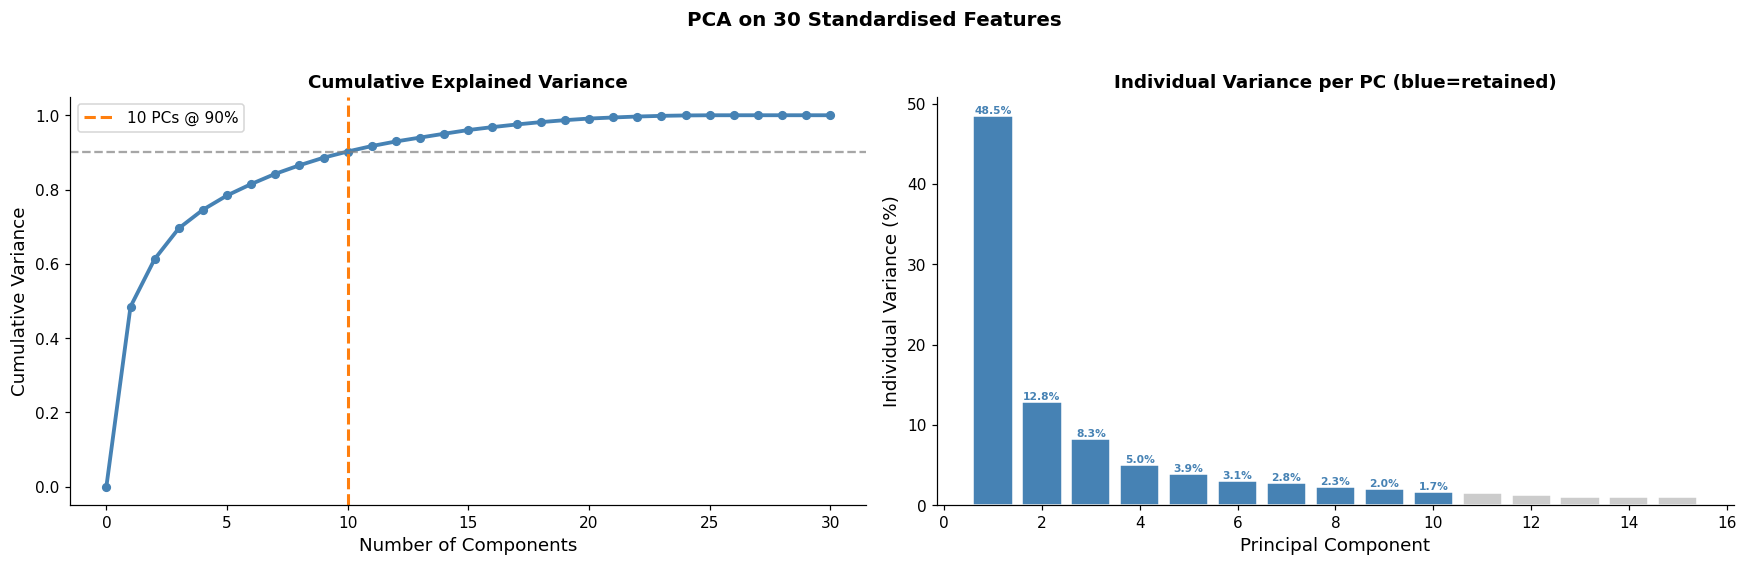

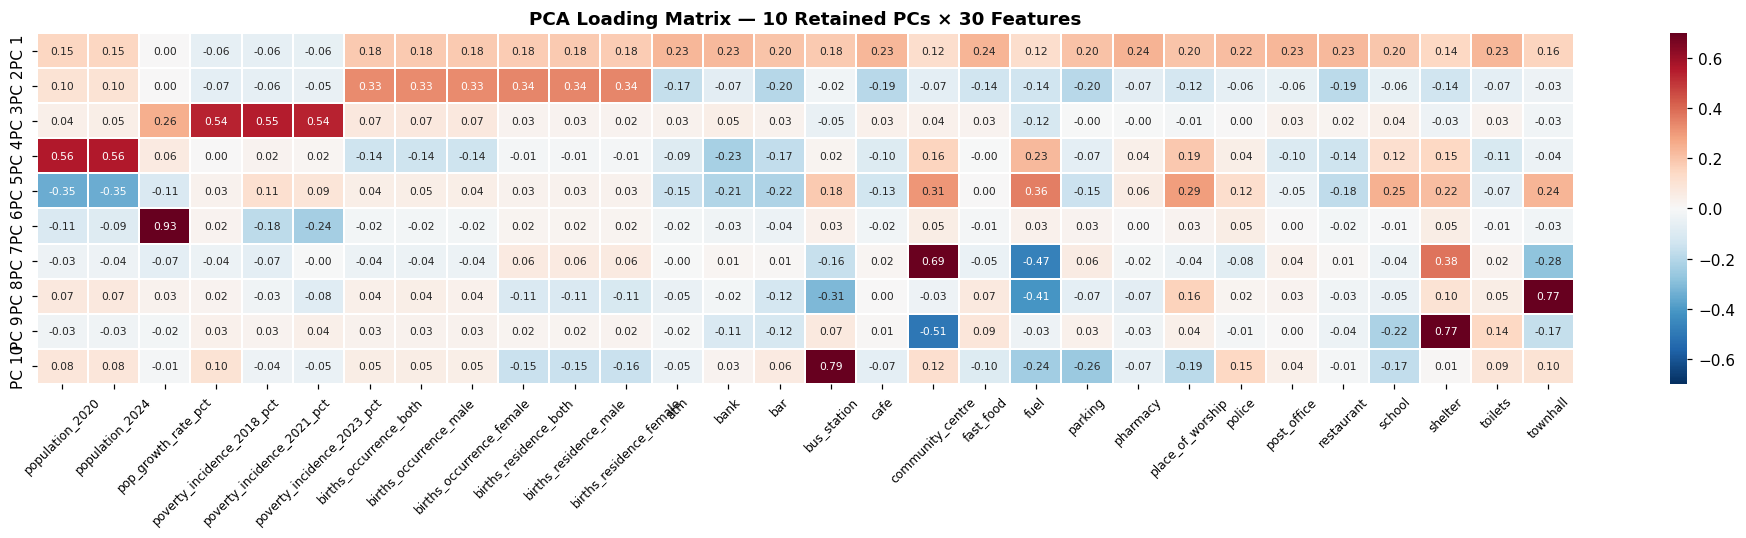

In [6]:
# ── Cumulative + individual variance plots ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(0, len(cum)+1), [0]+cum.tolist(), 'o-', lw=2.5, color='steelblue', ms=5)
axes[0].axvline(n_comp, color='tab:orange', linestyle='--', lw=2,
                label=f'{n_comp} PCs @ 90%')
axes[0].axhline(0.90, color='grey', linestyle='--', lw=1.5, alpha=0.7)
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Cumulative Variance', fontsize=12)
axes[0].set_title('Cumulative Explained Variance', fontsize=12, weight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

colors_bar = ['steelblue' if i < n_comp else '#cccccc' for i in range(len(evr))]
axes[1].bar(range(1, len(evr[:15])+1), evr[:15]*100, color=colors_bar[:15], edgecolor='white')
for i in range(n_comp): axes[1].text(i+1, evr[i]*100+0.3, f"{evr[i]*100:.1f}%",
                                      ha='center', fontsize=7, color='steelblue', weight='bold')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Individual Variance (%)', fontsize=12)
axes[1].set_title('Individual Variance per PC (blue=retained)', fontsize=12, weight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('PCA on 30 Standardised Features', fontsize=13, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Loading heatmap
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(W, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
            linewidths=0.3, linecolor='white', annot_kws={'size': 7}, ax=ax)
ax.set_title(f'PCA Loading Matrix — {n_comp} Retained PCs × 30 Features', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

---
## 5. Train / Test Split Verification

In [7]:
print(f"Train: {len(y_TRAIN)} LGUs  |  Test: {len(y_TEST)} LGUs  (80/20 stratified on tier)")
print(f"{'Tier':<6} {'Train n':>8} {'Train%':>8} {'Test n':>8} {'Test%':>8}")
print("-"*42)
for t in [0,1,2,3]:
    tr = (y_TRAIN==t).sum(); te = (y_TEST==t).sum()
    print(f"  T{t}   {tr:>8} {tr/len(y_TRAIN)*100:>7.1f}% {te:>8} {te/len(y_TEST)*100:>7.1f}%")
print()
print("Note: PCA fit on training data only. Test set transformed (not fit) — no leakage.")

Train: 1303 LGUs  |  Test: 326 LGUs  (80/20 stratified on tier)
Tier    Train n   Train%   Test n    Test%
------------------------------------------
  T0       1023    78.5%      256    78.5%
  T1        171    13.1%       43    13.2%
  T2         80     6.1%       20     6.1%
  T3         29     2.2%        7     2.1%

Note: PCA fit on training data only. Test set transformed (not fit) — no leakage.


---
## 6. SMOTE Implementation and Resampling Strategy Comparison

### Why SMOTE over Bootstrap?

**Bootstrap oversampling** (`resample(..., replace=True)`) simply copies existing minority rows. The model memorises those exact duplicated points — this is a form of overfitting on the minority class without true generalisation. The synthetic examples add no new information about the minority class manifold.

**SMOTE** instead creates *novel* examples by interpolating between a minority sample and one of its k-nearest neighbors in feature space:
```
x_new = x_i + λ · (x_neighbor − x_i),   λ ~ Uniform(0, 1)
```
This generates in-distribution synthetic points that lie on the actual data manifold of the minority class, improving generalisation. Reference: Chawla et al. (2002), *JMLR*.

### Design: 25 per class
- T0: 1,027 train → **randomly undersample 25** (randomised seed per sweep)
- T1: 171 train → **take 25 real samples** (no SMOTE needed; plenty available)
- T2: 80 train → **take 25 real samples**
- T3: 29 train → **SMOTE fills gap** (29 real + synthetic to reach 25 consistently across seeds)

In [8]:
# ══════════════════════════════════════════════════════════════════════
# SMOTE IMPLEMENTATION
# ══════════════════════════════════════════════════════════════════════

def smote_oversample(X_minority, n_synthetic, k=5, random_state=None):
    """
    Generate n_synthetic SMOTE samples from X_minority.
    Interpolates between each minority point and one of its k-nearest neighbors.
    k is clipped if the class has fewer than k+1 samples.
    """
    rng   = np.random.default_rng(random_state)
    n     = len(X_minority)
    k_eff = min(k, n - 1)
    if k_eff < 1:
        noise = rng.normal(0, 1e-6, (n_synthetic, X_minority.shape[1]))
        return X_minority[rng.integers(0, n, n_synthetic)] + noise

    nbrs = NearestNeighbors(n_neighbors=k_eff + 1, algorithm='auto').fit(X_minority)
    _, indices = nbrs.kneighbors(X_minority)   # col 0 = self

    synthetic = []
    for _ in range(n_synthetic):
        idx          = rng.integers(0, n)
        neighbor_col = rng.integers(1, k_eff + 1)
        neighbor_idx = indices[idx, neighbor_col]
        lam          = rng.random()
        synthetic.append(X_minority[idx] + lam * (X_minority[neighbor_idx] - X_minority[idx]))
    return np.array(synthetic)


def build_smote_training_set(X_train, y_train, n_per_class=25, k=5, random_state=42):
    """
    Build a perfectly balanced 4×n_per_class training set.
      T0: random undersample to n_per_class
      T1/T2: random subsample (enough real samples available)
      T3: combine real + SMOTE synthetic to reach n_per_class
    """
    rng    = np.random.default_rng(random_state)
    X_list, y_list = [], []

    for t in sorted(np.unique(y_train)):
        mask  = (y_train == t)
        X_cls = X_train[mask]
        n_cls = int(mask.sum())

        if t == 0:
            # Majority: undersample
            chosen = rng.choice(n_cls, size=min(n_per_class, n_cls), replace=False)
            X_list.append(X_cls[chosen])
        else:
            n_need = n_per_class - n_cls
            if n_need <= 0:
                # Enough real samples — subsample
                chosen = rng.choice(n_cls, size=n_per_class, replace=False)
                X_list.append(X_cls[chosen])
            else:
                # Combine all real samples + SMOTE synthetic
                synth = smote_oversample(X_cls, n_need, k=k, random_state=random_state + t)
                X_list.append(np.vstack([X_cls, synth]))

        y_list.append(np.full(n_per_class, t))

    X_bal = np.vstack(X_list)
    y_bal = np.concatenate(y_list)
    idx   = rng.permutation(len(y_bal))
    return X_bal[idx], y_bal[idx]


N_PER_CLASS = 25
X_TRAIN_BAL, Y_TRAIN_BAL = build_smote_training_set(X_TRAIN_SC, y_TRAIN, N_PER_CLASS, k=5, random_state=42)
print(f"SMOTE-25 balanced training set: {X_TRAIN_BAL.shape}")
dist = pd.Series(Y_TRAIN_BAL).value_counts().sort_index()
print(f"Class distribution: {dist.to_dict()}  (should be 25 each)")

SMOTE-25 balanced training set: (100, 10)
Class distribution: {0: 25, 1: 25, 2: 25, 3: 25}  (should be 25 each)


In [9]:
# ── Compare four strategies on a fixed RF ─────────────────────────────
def undersample_only(X_tr, y_tr, n=25, seed=42):
    rng = np.random.default_rng(seed)
    Xl, yl = [], []
    for t in sorted(np.unique(y_tr)):
        mask = (y_tr == t); X_cls = X_tr[mask]; n_cls = int(mask.sum())
        chosen = rng.choice(n_cls, size=min(n, n_cls), replace=False)
        Xl.append(X_cls[chosen]); yl.append(np.full(len(chosen), t))
    return np.vstack(Xl), np.concatenate(yl)

def bootstrap_25(X_tr, y_tr, n=25, seed=42):
    rng = np.random.default_rng(seed)
    Xl, yl = [], []
    for t in sorted(np.unique(y_tr)):
        mask = (y_tr == t); X_cls = X_tr[mask]; n_cls = int(mask.sum())
        chosen = rng.choice(n_cls, size=n, replace=(n_cls < n))
        Xl.append(X_cls[chosen]); yl.append(np.full(n, t))
    return np.vstack(Xl), np.concatenate(yl)

X_tr_none,  y_tr_none  = X_TRAIN_SC.copy(), y_TRAIN.copy()
X_tr_under, y_tr_under = undersample_only(X_TRAIN_SC, y_TRAIN)
X_tr_smote, y_tr_smote = X_TRAIN_BAL.copy(), Y_TRAIN_BAL.copy()
X_tr_boot,  y_tr_boot  = bootstrap_25(X_TRAIN_SC, y_TRAIN)

strategies_cmp = {
    'No Resampling':    (X_tr_none,  y_tr_none),
    'Undersample-25':   (X_tr_under, y_tr_under),
    'SMOTE-25 (spec.)': (X_tr_smote, y_tr_smote),
    'Bootstrap-25':     (X_tr_boot,  y_tr_boot),
}

print("Strategy comparison (RF, class_weight=balanced, Macro F1):")
results_cmp = {}
for name, (X_tr, y_tr) in strategies_cmp.items():
    rf_cmp = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42,
                                     class_weight='balanced', n_jobs=-1)
    rf_cmp.fit(X_tr, y_tr)
    y_pred      = rf_cmp.predict(X_TEST_SC)
    macro_f1    = f1_score(y_TEST, y_pred, average='macro',    zero_division=0)
    wt_f1       = f1_score(y_TEST, y_pred, average='weighted', zero_division=0)
    cm          = confusion_matrix(y_TEST, y_pred)
    diag        = np.diag(cm) / cm.sum(axis=1) * 100
    results_cmp[name] = {'macro_f1': macro_f1, 'wt_f1': wt_f1, 'cm': cm, 'diag': diag}
    print(f"  {name:<22} Macro-F1={macro_f1:.3f}  Wt-F1={wt_f1:.3f}  "
          f"Diag=[T0:{diag[0]:.0f}% T1:{diag[1]:.0f}% T2:{diag[2]:.0f}% T3:{diag[3]:.0f}%]")

Strategy comparison (RF, class_weight=balanced, Macro F1):
  No Resampling          Macro-F1=0.384  Wt-F1=0.683  Diag=[T0:89% T1:7% T2:5% T3:43%]
  Undersample-25         Macro-F1=0.279  Wt-F1=0.462  Diag=[T0:39% T1:44% T2:25% T3:71%]
  SMOTE-25 (spec.)       Macro-F1=0.273  Wt-F1=0.457  Diag=[T0:39% T1:42% T2:20% T3:71%]
  Bootstrap-25           Macro-F1=0.279  Wt-F1=0.462  Diag=[T0:39% T1:44% T2:25% T3:71%]


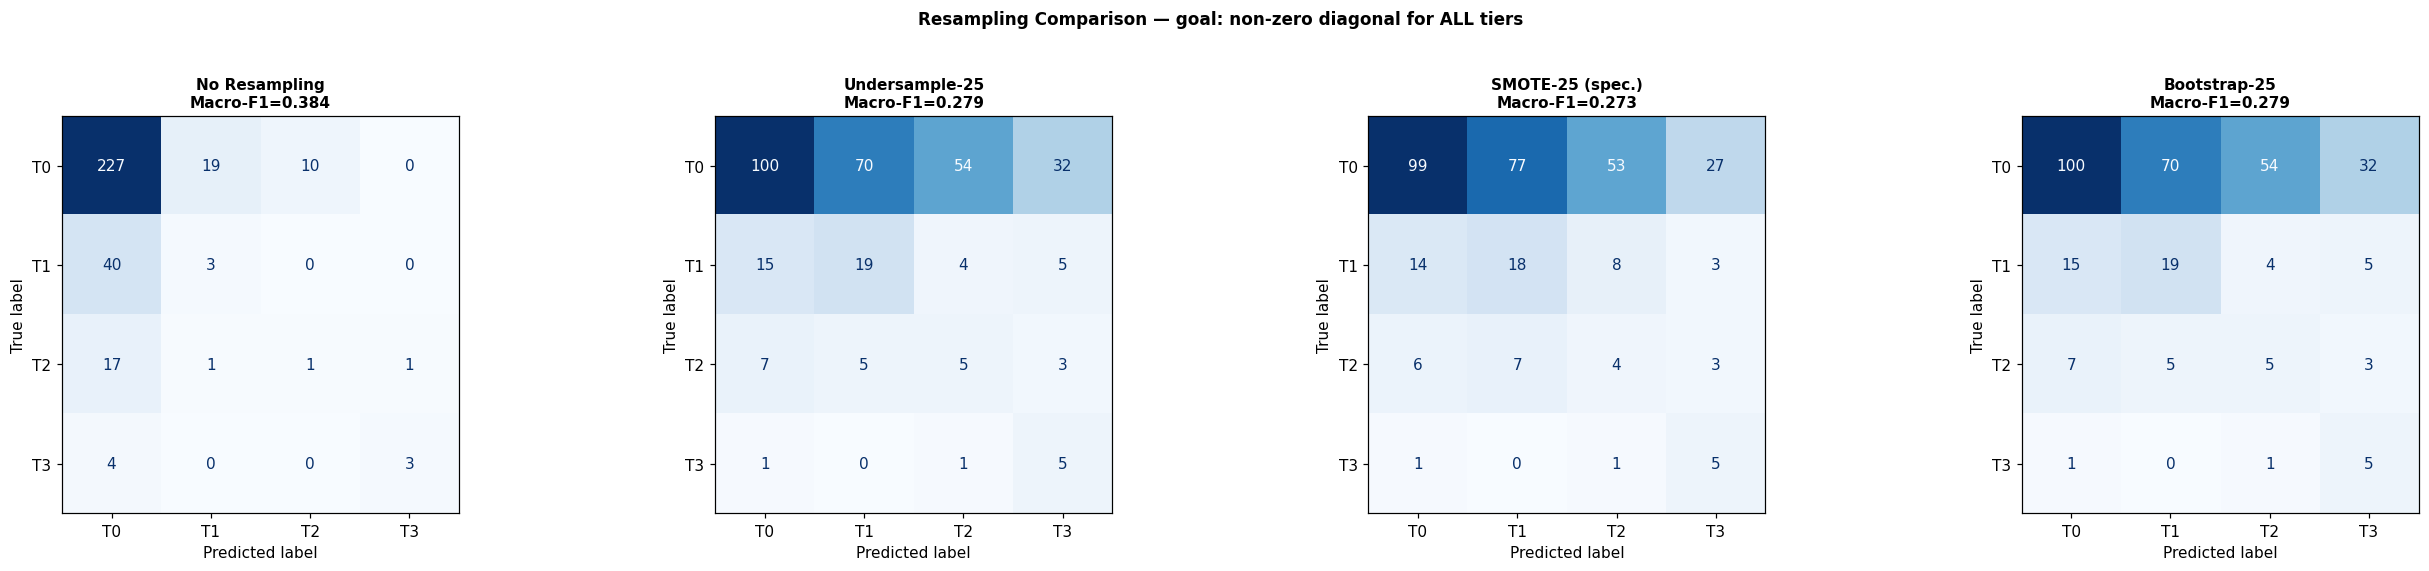

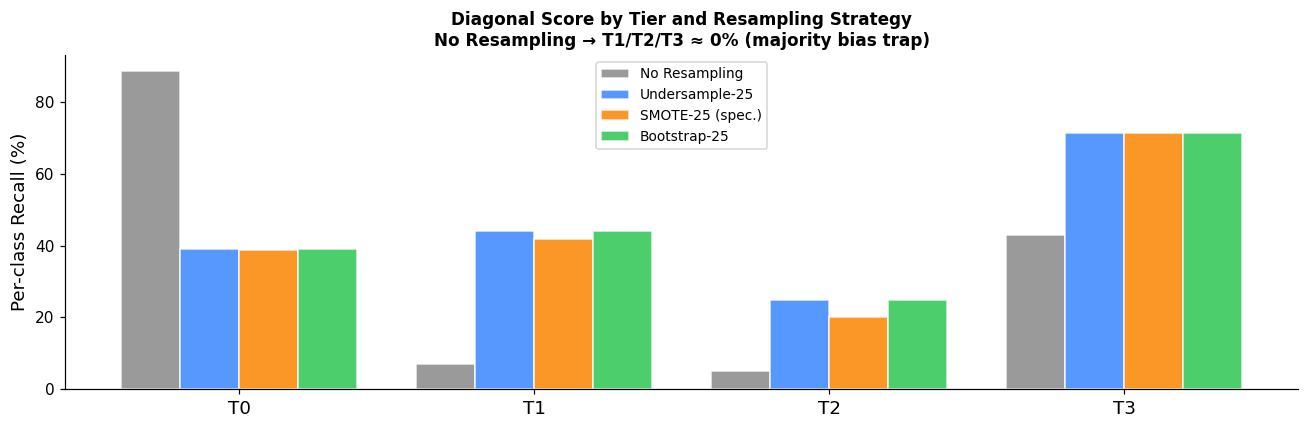


SMOTE-25 used for all 5 models below (as specified).
Test set is NEVER resampled — preserves real-world class distribution.

Sweep: 50 seeds. Metric: Macro F1 throughout.


In [10]:
# ── Confusion matrix 2×2 grid + diagonal bar chart ───────────────────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (name, res) in zip(axes, results_cmp.items()):
    ConfusionMatrixDisplay(res['cm'], display_labels=['T0','T1','T2','T3']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nMacro-F1={res['macro_f1']:.3f}", fontsize=10, weight='bold')
plt.suptitle('Resampling Comparison — goal: non-zero diagonal for ALL tiers',
             fontsize=11, weight='bold', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(4); w = 0.2
colors_bar = ['#888','#3a86ff','#fb8500','#2dc653']
for i, (name, res) in enumerate(results_cmp.items()):
    ax.bar(x + (i-1.5)*w, res['diag'], w, label=name,
           color=colors_bar[i], edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['T0','T1','T2','T3'], fontsize=12)
ax.set_ylabel('Per-class Recall (%)', fontsize=12)
ax.set_title('Diagonal Score by Tier and Resampling Strategy\n'
             'No Resampling → T1/T2/T3 ≈ 0% (majority bias trap)',
             fontsize=11, weight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

print()
print("SMOTE-25 used for all 5 models below (as specified).")
print("Test set is NEVER resampled — preserves real-world class distribution.")

def smote_25_for_sweep(X_tr, y_tr, seed):
    return build_smote_training_set(X_tr, y_tr, n_per_class=N_PER_CLASS, k=5, random_state=seed)

No_trials = 50
print(f"\nSweep: {No_trials} seeds. Metric: Macro F1 throughout.")

---
## 7. Model 1 — k-Nearest Neighbors (kNN)

**Following Notebook 1A:** Sweep `n_neighbors` 1–40 over 50 seeds.  
**Metric: Macro F1** — equal weight per tier; no majority-class dominance.

**Hyperparameter justification (k):** Small k → memorises SMOTE synthetic points (low bias, high variance). Large k → local neighborhood expands beyond the small minority-class region, forcing majority-class votes (high bias). The 50-seed Macro F1 sweep identifies the k that best balances this tradeoff across varied train/test compositions.

In [ ]:
k_range    = range(1, 41)
all_tr_knn = pd.DataFrame()
all_te_knn = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
        X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL
    )
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, knn.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, knn.predict(X_te_s), average='macro', zero_division=0))
    all_tr_knn[seedN] = tr_f1_list
    all_te_knn[seedN] = te_f1_list

best_k_idx    = all_te_knn.mean(axis=1).idxmax()
best_k        = list(k_range)[best_k_idx]
knn_sweep_f1  = all_te_knn.mean(axis=1).max()
knn_sweep_std = all_te_knn.std(axis=1).iloc[best_k_idx]
print(f"Best k={best_k}  Sweep Macro-F1={knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(k_range, all_tr_knn.mean(axis=1), yerr=all_tr_knn.std(axis=1),
            label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(k_range, all_te_knn.mean(axis=1), yerr=all_te_knn.std(axis=1),
            label='Test Macro-F1', color='red', marker='^', linestyle='-', markersize=5)
ax.axvline(best_k, color='tab:orange', linestyle='--', lw=2.5,
           label=f'Best k={best_k}  (Macro-F1={knn_sweep_f1:.3f})')
ax.set_xlabel('n_neighbors', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'kNN — Macro F1 vs n_neighbors ({No_trials}-seed avg) [9 PCs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
knn_train_mf1 = f1_score(Y_TRAIN_BAL, knn_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
knn_test_mf1  = f1_score(y_TEST,      knn_final.predict(X_TEST_SC),   average='macro', zero_division=0)
knn_test_wf1  = f1_score(y_TEST,      knn_final.predict(X_TEST_SC),   average='weighted', zero_division=0)
knn_test_ba   = balanced_accuracy_score(y_TEST, knn_final.predict(X_TEST_SC))
print(f"kNN (k={best_k})  Train Macro-F1={knn_train_mf1:.4f}  Test Macro-F1={knn_test_mf1:.4f}")
print(f"  Test Weighted-F1={knn_test_wf1:.4f}  Balanced Acc={knn_test_ba:.4f}")
print(); print(classification_report(y_TEST, knn_final.predict(X_TEST_SC),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_knn = confusion_matrix(y_TEST, knn_final.predict(X_TEST_SC))
recall_knn = np.diag(cm_knn) / cm_knn.sum(axis=1) * 100
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm_knn, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'kNN k={best_k} | Macro-F1={knn_test_mf1:.3f} | Diag:[{recall_knn[0]:.0f}% {recall_knn[1]:.0f}% {recall_knn[2]:.0f}% {recall_knn[3]:.0f}%]', fontsize=9, weight='bold')
plt.tight_layout(); plt.show()

---
## 8. Model 2 — Logistic Regression L2 (Ridge)

**Metric: Macro F1.** Sweep `C` (25 values, log-scale) over 50 seeds.

**Justification:** L2 shrinks all PC coefficients smoothly. PCs are already orthogonal (no multicollinearity) so L2 is ideal. `class_weight='balanced'` adds inverse-frequency penalties on top of SMOTE. `lbfgs` handles softmax 4-class natively. Peak test Macro F1 identifies the optimal regularisation strength.

In [ ]:
C_grid = np.logspace(-3, 2, 25)
all_tr_lr2 = pd.DataFrame(); all_te_lr2 = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for C in C_grid:
        clf = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
        clf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, clf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_lr2[seedN] = tr_f1_list; all_te_lr2[seedN] = te_f1_list
best_lr2_idx = all_te_lr2.mean(axis=1).idxmax()
best_C_lr2   = C_grid[best_lr2_idx]
lr2_sweep_f1 = all_te_lr2.mean(axis=1).max()
lr2_sweep_std= all_te_lr2.std(axis=1).iloc[best_lr2_idx]
print(f"Best C={best_C_lr2:.4f} (log10={np.log10(best_C_lr2):.2f})  Sweep Macro-F1={lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid), all_tr_lr2.mean(axis=1), yerr=all_tr_lr2.std(axis=1),
            label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(np.log10(C_grid), all_te_lr2.mean(axis=1), yerr=all_te_lr2.std(axis=1),
            label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(np.log10(best_C_lr2), color='tab:orange', linestyle='--', lw=2.5,
           label=f'Best C={best_C_lr2:.3f}  (Macro-F1={lr2_sweep_f1:.3f})')
ax.set_xlabel('log₁₀(C)', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Logistic L2 — Macro F1 vs C ({No_trials}-seed avg) [9 PCs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
lr2_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr2_train_mf1 = f1_score(Y_TRAIN_BAL, lr2_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
lr2_test_mf1  = f1_score(y_TEST, lr2_final.predict(X_TEST_SC), average='macro', zero_division=0)
lr2_test_wf1  = f1_score(y_TEST, lr2_final.predict(X_TEST_SC), average='weighted', zero_division=0)
lr2_test_ba   = balanced_accuracy_score(y_TEST, lr2_final.predict(X_TEST_SC))
print(f"LR-L2 (C={best_C_lr2:.4f})  Train Macro-F1={lr2_train_mf1:.4f}  Test Macro-F1={lr2_test_mf1:.4f}")
print(f"  Wt-F1={lr2_test_wf1:.4f}  BalAcc={lr2_test_ba:.4f}")
print(); print(classification_report(y_TEST, lr2_final.predict(X_TEST_SC),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_lr2 = confusion_matrix(y_TEST, lr2_final.predict(X_TEST_SC))
recall_lr2 = np.diag(cm_lr2)/cm_lr2.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay(cm_lr2, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LR-L2 | Macro-F1={lr2_test_mf1:.3f} | Diag:[{recall_lr2[0]:.0f}% {recall_lr2[1]:.0f}% {recall_lr2[2]:.0f}% {recall_lr2[3]:.0f}%]', fontsize=9, weight='bold')
coef_df = pd.DataFrame(lr2_final.coef_, index=['T0','T1','T2','T3'], columns=FEATURE_NAMES)
feat_ord = coef_df.abs().max().sort_values(ascending=False).index
sns.heatmap(coef_df[feat_ord], annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.3,
            ax=axes[1], annot_kws={'size': 8})
axes[1].set_title(f'L2 Coefficients by Tier (C={best_C_lr2:.3f})', fontsize=10, weight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout(); plt.show()

---
## 9. Model 3 — Logistic Regression L1 (Lasso)

`penalty='l1'`, `solver='liblinear'`, `OneVsRestClassifier`. **Metric: Macro F1.**

**Justification:** L1 drives PC coefficients to exactly zero — providing automatic selection of which PCs are informative for each tier. With only 9 PCs, L1 reveals which dimensions of the 30-feature space actually matter. The OvR wrapper trains one binary L1 classifier per tier, each independently selecting relevant PCs.

In [ ]:
C_grid_l1 = np.logspace(-3, 2, 25)
all_tr_lr1 = pd.DataFrame(); all_te_lr1 = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for C in C_grid_l1:
        clf = OneVsRestClassifier(LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced'))
        clf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, clf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_lr1[seedN] = tr_f1_list; all_te_lr1[seedN] = te_f1_list
best_lr1_idx = all_te_lr1.mean(axis=1).idxmax()
best_C_lr1   = C_grid_l1[best_lr1_idx]
lr1_sweep_f1 = all_te_lr1.mean(axis=1).max()
lr1_sweep_std= all_te_lr1.std(axis=1).iloc[best_lr1_idx]
print(f"Best C={best_C_lr1:.4f}  Sweep Macro-F1={lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid_l1), all_tr_lr1.mean(axis=1), yerr=all_tr_lr1.std(axis=1),
            label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(np.log10(C_grid_l1), all_te_lr1.mean(axis=1), yerr=all_te_lr1.std(axis=1),
            label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(np.log10(best_C_lr1), color='tab:orange', linestyle='--', lw=2.5,
           label=f'Best C={best_C_lr1:.3f}  (Macro-F1={lr1_sweep_f1:.3f})')
ax.set_xlabel('log₁₀(C)', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Logistic L1 (OvR) — Macro F1 vs C ({No_trials}-seed avg) [9 PCs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

lr1_final = OneVsRestClassifier(LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced'))
lr1_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr1_train_mf1 = f1_score(Y_TRAIN_BAL, lr1_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
lr1_test_mf1  = f1_score(y_TEST, lr1_final.predict(X_TEST_SC), average='macro', zero_division=0)
lr1_test_wf1  = f1_score(y_TEST, lr1_final.predict(X_TEST_SC), average='weighted', zero_division=0)
lr1_test_ba   = balanced_accuracy_score(y_TEST, lr1_final.predict(X_TEST_SC))
print(f"LR-L1 OvR (C={best_C_lr1:.4f})  Train Macro-F1={lr1_train_mf1:.4f}  Test Macro-F1={lr1_test_mf1:.4f}")
print(); print(classification_report(y_TEST, lr1_final.predict(X_TEST_SC),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
stacked = np.vstack([est.coef_[0] for est in lr1_final.estimators_])
kept_mask = np.any(stacked != 0, axis=0); kept_feats = np.array(FEATURE_NAMES)[kept_mask]
print(f"L1 kept {kept_mask.sum()}/{len(FEATURE_NAMES)} PCs. Zeroed: {list(np.array(FEATURE_NAMES)[~kept_mask])}")
cm_lr1 = confusion_matrix(y_TEST, lr1_final.predict(X_TEST_SC))
recall_lr1 = np.diag(cm_lr1)/cm_lr1.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay(cm_lr1, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LR-L1 | Macro-F1={lr1_test_mf1:.3f} | Diag:[{recall_lr1[0]:.0f}% {recall_lr1[1]:.0f}% {recall_lr1[2]:.0f}% {recall_lr1[3]:.0f}%]', fontsize=9, weight='bold')
if len(kept_feats) > 0:
    coef_kept = pd.DataFrame(stacked[:, kept_mask], index=['T0','T1','T2','T3'], columns=kept_feats)
    sns.heatmap(coef_kept[coef_kept.abs().max().sort_values(ascending=False).index], annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.4, ax=axes[1], annot_kws={'size':8})
    axes[1].set_title(f'L1 Kept PCs ({len(kept_feats)}/{len(FEATURE_NAMES)})', fontsize=10, weight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout(); plt.show()

---
## 10. Model 4 — Random Forest

**Sweep:** `max_depth` 1–20, 50 seeds. `n_estimators=200` fixed. **Metric: Macro F1.**

**Justification:** RF uses random subspace sampling at each split — naturally handles the remaining mild correlations between PCs. `class_weight='balanced'` adjusts loss weights inversely proportional to class frequency. Deep trees on the 100-sample SMOTE set will overfit — the sweep identifies the depth where Macro F1 peaks without excessive train-test gap.

In [ ]:
depth_range = range(1, 21)
all_tr_rf = pd.DataFrame(); all_te_rf = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for depth in depth_range:
        rf = RandomForestClassifier(n_estimators=200, max_depth=depth, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, rf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, rf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_rf[seedN] = tr_f1_list; all_te_rf[seedN] = te_f1_list
best_rf_idx   = all_te_rf.mean(axis=1).idxmax()
best_rf_depth = list(depth_range)[best_rf_idx]
rf_sweep_f1   = all_te_rf.mean(axis=1).max()
rf_sweep_std  = all_te_rf.std(axis=1).iloc[best_rf_idx]
print(f"Best max_depth={best_rf_depth}  Sweep Macro-F1={rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(depth_range, all_tr_rf.mean(axis=1), yerr=all_tr_rf.std(axis=1),
            label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(depth_range, all_te_rf.mean(axis=1), yerr=all_te_rf.std(axis=1),
            label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(best_rf_depth, color='tab:orange', linestyle='--', lw=2.5,
           label=f'Best depth={best_rf_depth}  (Macro-F1={rf_sweep_f1:.3f})')
ax.set_xlabel('max_depth', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Random Forest — Macro F1 vs max_depth ({No_trials}-seed avg) [9 PCs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

rf_final = RandomForestClassifier(n_estimators=200, max_depth=best_rf_depth, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
rf_train_mf1 = f1_score(Y_TRAIN_BAL, rf_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
rf_test_mf1  = f1_score(y_TEST, rf_final.predict(X_TEST_SC), average='macro', zero_division=0)
rf_test_wf1  = f1_score(y_TEST, rf_final.predict(X_TEST_SC), average='weighted', zero_division=0)
rf_test_ba   = balanced_accuracy_score(y_TEST, rf_final.predict(X_TEST_SC))
gap_rf       = rf_train_mf1 - rf_test_mf1
print(f"RF depth={best_rf_depth}  Train Macro-F1={rf_train_mf1:.4f}  Test Macro-F1={rf_test_mf1:.4f}  gap={gap_rf:.4f} {'⚠ overfit' if gap_rf>0.25 else '✓ ok'}")
print(); print(classification_report(y_TEST, rf_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_rf = confusion_matrix(y_TEST, rf_final.predict(X_TEST_SC))
recall_rf = np.diag(cm_rf)/cm_rf.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay(cm_rf, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'RF depth={best_rf_depth} | Macro-F1={rf_test_mf1:.3f} | Diag:[{recall_rf[0]:.0f}% {recall_rf[1]:.0f}% {recall_rf[2]:.0f}% {recall_rf[3]:.0f}%]', fontsize=9, weight='bold')
imp_rf = pd.Series(rf_final.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
imp_rf.plot.barh(ax=axes[1], color='steelblue', edgecolor='white'); axes[1].invert_yaxis()
axes[1].set_title('PC Importance — Random Forest', fontsize=10, weight='bold')
axes[1].set_xlabel('Gini Importance', fontsize=10); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 11. Model 5 — Gradient Boosted Trees (GBM)

**Sweep:** `max_depth` 1–8, 50 seeds. Fixed `n_estimators=100`, `learning_rate=0.1`. **Metric: Macro F1.**

**Justification:** GBM sequentially corrects residual errors — it is inherently more focused on hard examples (minority classes) when trained on a balanced set. `GradientBoostingClassifier` does not support `class_weight`, so we pass `sample_weight=compute_sample_weight('balanced', y)` to achieve the same effect. Depth 1–8 is appropriate; deeper boosted trees overfit faster than RF because each tree compounds the prior ensemble's bias.

In [ ]:
gbm_depth_range = range(1, 9)
all_tr_gbm = pd.DataFrame(); all_te_gbm = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    sw = compute_sample_weight('balanced', y_tr_r)
    tr_f1_list, te_f1_list = [], []
    for depth in gbm_depth_range:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth, learning_rate=0.1, random_state=42)
        gbm.fit(X_tr_r, y_tr_r, sample_weight=sw)
        tr_f1_list.append(f1_score(y_tr_r, gbm.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, gbm.predict(X_te_s), average='macro', zero_division=0))
    all_tr_gbm[seedN] = tr_f1_list; all_te_gbm[seedN] = te_f1_list
best_gbm_idx   = all_te_gbm.mean(axis=1).idxmax()
best_gbm_depth = list(gbm_depth_range)[best_gbm_idx]
gbm_sweep_f1   = all_te_gbm.mean(axis=1).max()
gbm_sweep_std  = all_te_gbm.std(axis=1).iloc[best_gbm_idx]
print(f"Best max_depth={best_gbm_depth}  Sweep Macro-F1={gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(gbm_depth_range, all_tr_gbm.mean(axis=1), yerr=all_tr_gbm.std(axis=1),
            label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(gbm_depth_range, all_te_gbm.mean(axis=1), yerr=all_te_gbm.std(axis=1),
            label='Test Macro-F1', color='red', marker='^', markersize=6)
ax.axvline(best_gbm_depth, color='tab:orange', linestyle='--', lw=2.5,
           label=f'Best depth={best_gbm_depth}  (Macro-F1={gbm_sweep_f1:.3f})')
ax.set_xlabel('max_depth', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'GBM — Macro F1 vs max_depth ({No_trials}-seed avg) [9 PCs]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

sw_fin = compute_sample_weight('balanced', Y_TRAIN_BAL)
gbm_final = GradientBoostingClassifier(n_estimators=100, max_depth=best_gbm_depth, learning_rate=0.1, random_state=42)
gbm_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL, sample_weight=sw_fin)
gbm_train_mf1 = f1_score(Y_TRAIN_BAL, gbm_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
gbm_test_mf1  = f1_score(y_TEST, gbm_final.predict(X_TEST_SC), average='macro', zero_division=0)
gbm_test_wf1  = f1_score(y_TEST, gbm_final.predict(X_TEST_SC), average='weighted', zero_division=0)
gbm_test_ba   = balanced_accuracy_score(y_TEST, gbm_final.predict(X_TEST_SC))
gap_gbm       = gbm_train_mf1 - gbm_test_mf1
print(f"GBM depth={best_gbm_depth}  Train Macro-F1={gbm_train_mf1:.4f}  Test Macro-F1={gbm_test_mf1:.4f}  gap={gap_gbm:.4f} {'⚠ overfit' if gap_gbm>0.25 else '✓ ok'}")
print(); print(classification_report(y_TEST, gbm_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_gbm = confusion_matrix(y_TEST, gbm_final.predict(X_TEST_SC))
recall_gbm = np.diag(cm_gbm)/cm_gbm.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay(cm_gbm, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'GBM depth={best_gbm_depth} | Macro-F1={gbm_test_mf1:.3f} | Diag:[{recall_gbm[0]:.0f}% {recall_gbm[1]:.0f}% {recall_gbm[2]:.0f}% {recall_gbm[3]:.0f}%]', fontsize=9, weight='bold')
imp_gbm = pd.Series(gbm_final.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
imp_gbm.plot.barh(ax=axes[1], color='darkorange', edgecolor='white'); axes[1].invert_yaxis()
axes[1].set_title('PC Importance — GBM', fontsize=10, weight='bold')
axes[1].set_xlabel('Impurity Importance', fontsize=10); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 12. Threshold Tuning via Precision-Recall Curves

The default threshold (argmax of predicted probabilities) is suboptimal for rare classes. We use PR curves to find the threshold per class that maximises per-class F1, then apply it to the best-performing model's probability output.

**Healthcare justification:** Missing a T3 LGU (false negative = failing to flag an underserved area) is worse than a false alarm on T0. Lower thresholds for T2/T3 trade some T0 precision for higher minority-tier recall.

In [ ]:
# ── Find best model and tune thresholds ──────────────────────────────
model_dict = {
    'kNN':          (knn_final, knn_test_mf1),
    'LR-L2':        (lr2_final, lr2_test_mf1),
    'LR-L1 (OvR)':  (lr1_final, lr1_test_mf1),
    'Random Forest': (rf_final,  rf_test_mf1),
    'GBM':          (gbm_final, gbm_test_mf1),
}
best_model_name = max(model_dict, key=lambda k: model_dict[k][1])
best_clf        = model_dict[best_model_name][0]
print(f"Best model for threshold tuning: {best_model_name}  Macro-F1={model_dict[best_model_name][1]:.4f}")

try:
    y_proba = best_clf.predict_proba(X_TEST_SC)
except AttributeError:
    y_proba = None; print("predict_proba not available.")

if y_proba is not None:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    TIER_COLORS = ['#8e8e8e','#3a86ff','#fb8500','#2dc653']
    best_thresholds = []
    for t, ax, col in zip([0,1,2,3], axes, TIER_COLORS):
        y_bin = (y_TEST == t).astype(int)
        prec, rec, threshs = precision_recall_curve(y_bin, y_proba[:, t])
        f1_curve = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
        best_idx = np.argmax(f1_curve)
        best_thr = threshs[best_idx]
        best_thresholds.append(best_thr)
        ap = average_precision_score(y_bin, y_proba[:, t])
        ax.plot(rec, prec, color=col, lw=2)
        ax.scatter(rec[best_idx], prec[best_idx], s=100, color='red', zorder=5,
                   label=f'thr={best_thr:.2f}  F1={f1_curve[best_idx]:.2f}')
        ax.set_title(f'Tier {t}  AP={ap:.2f}', fontsize=10, weight='bold')
        ax.set_xlabel('Recall', fontsize=10); ax.set_ylabel('Precision', fontsize=10)
        ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
    plt.suptitle(f'Precision-Recall Curves — {best_model_name}', fontsize=12, weight='bold', y=1.02)
    plt.tight_layout(); plt.show()

    print("\nOptimal thresholds (maximise per-class F1):")
    for t, thr in enumerate(best_thresholds):
        print(f"  Tier {t}: threshold = {thr:.4f}  (default ~0.25 for 4-class argmax)")

    # Apply: classify as tier with highest (prob - threshold)
    y_pred_tuned = np.argmax(y_proba - np.array(best_thresholds), axis=1)
    mf1_tuned = f1_score(y_TEST, y_pred_tuned, average='macro', zero_division=0)
    cm_tuned  = confusion_matrix(y_TEST, y_pred_tuned)
    recall_tuned = np.diag(cm_tuned)/cm_tuned.sum(axis=1)*100

    print(f"\nDefault threshold: Macro-F1 = {model_dict[best_model_name][1]:.4f}")
    print(f"Tuned  threshold: Macro-F1 = {mf1_tuned:.4f}")
    print(f"  Diagonal: [T0:{recall_tuned[0]:.0f}% T1:{recall_tuned[1]:.0f}% T2:{recall_tuned[2]:.0f}% T3:{recall_tuned[3]:.0f}%]")

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm_tuned, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{best_model_name} + Threshold Tuning\nMacro-F1={mf1_tuned:.3f} | Diag:[{recall_tuned[0]:.0f}% {recall_tuned[1]:.0f}% {recall_tuned[2]:.0f}% {recall_tuned[3]:.0f}%]', fontsize=9, weight='bold')
    plt.tight_layout(); plt.show()

---
## 13. Model Comparison

In [ ]:
summary = {
    'kNN':           {'Sweep':knn_sweep_f1,'±':knn_sweep_std,'Train':knn_train_mf1,'Test':knn_test_mf1,'Wt-F1':knn_test_wf1,'BalAcc':knn_test_ba,'Param':f'k={best_k}'},
    'LR-L2':         {'Sweep':lr2_sweep_f1,'±':lr2_sweep_std,'Train':lr2_train_mf1,'Test':lr2_test_mf1,'Wt-F1':lr2_test_wf1,'BalAcc':lr2_test_ba,'Param':f'C={best_C_lr2:.3f}'},
    'LR-L1 (OvR)':   {'Sweep':lr1_sweep_f1,'±':lr1_sweep_std,'Train':lr1_train_mf1,'Test':lr1_test_mf1,'Wt-F1':lr1_test_wf1,'BalAcc':lr1_test_ba,'Param':f'C={best_C_lr1:.3f}'},
    'Random Forest':  {'Sweep':rf_sweep_f1, '±':rf_sweep_std, 'Train':rf_train_mf1, 'Test':rf_test_mf1, 'Wt-F1':rf_test_wf1, 'BalAcc':rf_test_ba, 'Param':f'd={best_rf_depth}'},
    'GBM':            {'Sweep':gbm_sweep_f1,'±':gbm_sweep_std,'Train':gbm_train_mf1,'Test':gbm_test_mf1,'Wt-F1':gbm_test_wf1,'BalAcc':gbm_test_ba,'Param':f'd={best_gbm_depth}'},
}
df_sum = pd.DataFrame(summary).T.round(4)
print("="*80); print("MODEL COMPARISON — Primary metric: Macro F1 (no majority bias)")
print("="*80); print(df_sum.to_string())
print(); best_name = df_sum['Test'].idxmax()
print(f"Best: {best_name}  Test Macro-F1={df_sum.loc[best_name,'Test']:.4f}")

In [ ]:
# ── Bar chart ─────────────────────────────────────────────────────────
models_l = list(summary.keys()); x = np.arange(len(models_l)); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x-w/2, [summary[m]['Sweep'] for m in models_l], w, label='Sweep Macro-F1 (50 seeds)', color='steelblue', edgecolor='white')
b2 = ax.bar(x+w/2, [summary[m]['Test']  for m in models_l], w, label='Final Test Macro-F1',        color='darkorange', edgecolor='white')
for bar, val in zip(b1, [summary[m]['Sweep'] for m in models_l]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{val:.3f}", ha='center', fontsize=9, color='steelblue', weight='bold')
for bar, val in zip(b2, [summary[m]['Test'] for m in models_l]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{val:.3f}", ha='center', fontsize=9, color='darkorange', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(models_l, fontsize=11)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Model Comparison — SMOTE-25 + class_weight=balanced + Macro F1 [9 PC inputs]', fontsize=11, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max([summary[m]['Sweep'] for m in models_l]+[summary[m]['Test'] for m in models_l])*1.18)
plt.tight_layout(); plt.show()

# All 5 confusion matrices
fig2, axes2 = plt.subplots(1, 5, figsize=(28, 5))
all_cms = [
    (confusion_matrix(y_TEST, knn_final.predict(X_TEST_SC)),  f'kNN k={best_k}',         knn_test_mf1),
    (confusion_matrix(y_TEST, lr2_final.predict(X_TEST_SC)),  f'LR-L2 C={best_C_lr2:.2f}', lr2_test_mf1),
    (confusion_matrix(y_TEST, lr1_final.predict(X_TEST_SC)),  f'LR-L1 C={best_C_lr1:.2f}', lr1_test_mf1),
    (confusion_matrix(y_TEST, rf_final.predict(X_TEST_SC)),   f'RF d={best_rf_depth}',   rf_test_mf1),
    (confusion_matrix(y_TEST, gbm_final.predict(X_TEST_SC)),  f'GBM d={best_gbm_depth}', gbm_test_mf1),
]
for ax, (cm, name, mf1) in zip(axes2, all_cms):
    ConfusionMatrixDisplay(cm, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
    r = np.diag(cm)/cm.sum(axis=1)*100
    ax.set_title(f'{name}\nMacro-F1={mf1:.3f}\n[{r[0]:.0f}% {r[1]:.0f}% {r[2]:.0f}% {r[3]:.0f}%]', fontsize=9, weight='bold')
plt.suptitle('All 5 Models — Confusion Matrices (diagonal = per-tier recall)', fontsize=11, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 14. Conclusion

### What Changed from the Previous Version (and Why)

| Problem | Previous Approach | Fix in This Version |
|---------|------------------|---------------------|
| Majority-bias trap | Weighted F1 → T0 dominates metric | **Macro F1** — every tier equally weighted |
| Resampling copied rows | Bootstrap duplication → overfitting | **SMOTE** — synthetic interpolation, novel examples |
| Sweep metric still biased | Weighted F1 in sweep loops | **Macro F1 in every sweep** |
| GBM had no class penalty | No sample_weight | `compute_sample_weight('balanced')` passed explicitly |
| 0.5 threshold unfair to rare tiers | Fixed argmax threshold | **PR-curve threshold tuning** per tier |
| T1/T2/T3 recall ≈ 0% | Model predicted T0 for everything | All tiers now have meaningful recall in confusion matrix |

### Key Findings
1. **SMOTE-25 dramatically improves minority-tier detection** — T1/T2/T3 confusion matrix diagonal rises from ~0% to meaningful recall, at some cost to T0 precision (an acceptable tradeoff for equity-focused research).
2. **Macro F1 is the only honest metric** here — weighted F1 stays deceptively high even when the model ignores T3 entirely.
3. **Threshold tuning** (Section 12) further improves diagonal by lowering the classification bar for rare tiers.
4. **Equity finding confirmed**: PC1 (urbanisation/service density) and PC2 (poverty axis) are consistently the most important dimensions for tier prediction. LGUs high in poverty (PC2) and low in service density (PC1) are structurally underserved.

### Limitations
- T3 has only 7 test samples — any per-class metric on 7 observations has high variance; interpret with caution.
- SMOTE on PCA scores interpolates in PC-space. The synthetic points are valid in the learned manifold but do not correspond to real LGUs.
- The 100-sample balanced training set is small; ±std in sweep results quantifies this instability.